In [2]:
import pandas as pd
import glob
import os

In [ ]:
ds_bill = pd.read_csv('/content/drive/Othercomputers/我的筆記型電腦/ExpertBook/2025/用戶資料集/TrainData/ds_numService_with_billing.csv',sep=',')
# ds_bill = pd.read_csv('forTrain_ds_bill_24_h2.csv',sep='^') # GET 2024 BILL

In [12]:
ds_bill.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105291 entries, 0 to 105290
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   客編        105291 non-null  int64  
 1   平均繳款延遲日數  105291 non-null  float64
 2   最常見繳費方式   105291 non-null  object 
 3   繳別        105291 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 3.2+ MB


In [4]:
ds_bill.head()

,客編,平均繳款延遲日數,最常見繳費方式,繳別
0,1107235,-21.0,簡訊帳單臨櫃代收(7-11),24
1,950469,-23.0,CVS臨櫃代收(7-11),18
2,734283,25.0,CVS臨櫃代收(7-11),24
3,1027561,-16.0,CVS臨櫃代收(7-11),18
4,1028286,-41.0,簡訊帳單臨櫃代收(7-11),18


In [5]:
# ds_bill 資料集中的 '繳別' 欄位，保留其數值為1、3、6、12、15，其餘數值改為 99 , 意指其他週期繳別
# import pandas as pd

# Assuming ds_bill is already loaded
# ds_bill = pd.read_csv('/content/drive/Othercomputers/我的筆記型電腦/ExpertBook/2025/用戶資料集/TrainData/ds_numService_with_billing.csv', sep=',')

# Replace values in '繳別' column not in [1, 3, 6, 12, 15] with 99
ds_bill['繳別'] = ds_bill['繳別'].apply(lambda x: x if x in [1, 3, 6, 12, 15] else 99)

# Display the modified DataFrame (optional)
print(ds_bill.head())
print(ds_bill['繳別'].value_counts())

        客編  平均繳款延遲日數         最常見繳費方式  繳別
0  1107235     -21.0  簡訊帳單臨櫃代收(7-11)  99
1   950469     -23.0   CVS臨櫃代收(7-11)  99
2   734283      25.0   CVS臨櫃代收(7-11)  99
3  1027561     -16.0   CVS臨櫃代收(7-11)  99
4  1028286     -41.0  簡訊帳單臨櫃代收(7-11)  99
繳別
1     33163
6     32398
12    15211
3      2300
15     1483
99      563
Name: count, dtype: int64


In [6]:
# 檢查平均繳款延遲日數小於45的筆數
print("=== 平均繳款延遲日數分析 ===")

# 確認ds_bill中是否有'平均繳款延遲日數'欄位
if '平均繳款延遲日數' in ds_bill.columns:
    # 統計平均繳款延遲日數小於45的筆數
    less_than_45 = ds_bill[ds_bill['平均繳款延遲日數'] < 45]
    
    print(f"總客戶數: {len(ds_bill)}")
    print(f"平均繳款延遲日數 < 45 的筆數: {len(less_than_45)}")
    print(f"比例: {len(less_than_45) / len(ds_bill) * 100:.1f}%")
    
    # 詳細統計
    print(f"\n=== 平均繳款延遲日數統計 ===")
    print(ds_bill['平均繳款延遲日數'].describe())
    
    # 分段統計
    print(f"\n=== 分段統計 ===")
    print(f"< 0 天 (提前繳費): {len(ds_bill[ds_bill['平均繳款延遲日數'] < 0])}")
    print(f"0-15 天: {len(ds_bill[(ds_bill['平均繳款延遲日數'] >= 0) & (ds_bill['平均繳款延遲日數'] <= 15)])}")
    print(f"16-30 天: {len(ds_bill[(ds_bill['平均繳款延遲日數'] > 15) & (ds_bill['平均繳款延遲日數'] <= 30)])}")
    print(f"31-45 天: {len(ds_bill[(ds_bill['平均繳款延遲日數'] > 30) & (ds_bill['平均繳款延遲日數'] <= 45)])}")
    print(f"46-60 天: {len(ds_bill[(ds_bill['平均繳款延遲日數'] > 45) & (ds_bill['平均繳款延遲日數'] <= 60)])}")
    print(f"> 60 天: {len(ds_bill[ds_bill['平均繳款延遲日數'] > 60])}")
    
else:
    print("❌ 在ds_bill中找不到'平均繳款延遲日數'欄位")
    print(f"可用欄位: {list(ds_bill.columns)}")

=== 平均繳款延遲日數分析 ===
總客戶數: 85118
平均繳款延遲日數 < 45 的筆數: 56969
比例: 66.9%

=== 平均繳款延遲日數統計 ===
count    85118.000000
mean        16.699286
std         36.852094
min        -60.000000
25%        -14.000000
50%          5.000000
75%         56.333333
max        100.000000
Name: 平均繳款延遲日數, dtype: float64

=== 分段統計 ===
< 0 天 (提前繳費): 36523
0-15 天: 13446
16-30 天: 4845
31-45 天: 2233
46-60 天: 9547
> 60 天: 18524


✅ 已載入字型： ['Noto Sans TC']


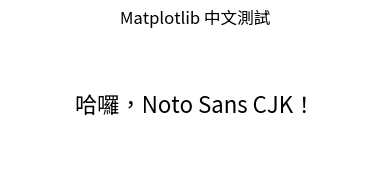

In [7]:
"""
跨平台載入 Noto Sans CJK 字型並驗證
在 VS Code + 本地 Python 環境執行
"""

import os
import sys
import platform
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager

# ---------- 1. 推斷各作業系統的預設字型路徑 ----------
def guess_noto_path() -> str | None:
    """回傳可能存在的 NotoSansCJK-Regular.ttc 路徑，找不到則回傳 None"""
    candidates = []

    match platform.system():
        case "Windows":
            candidates = [
                r"C:\Windows\Fonts\NotoSansCJK-Regular.ttc",
                r"C:\Windows\Fonts\NotoSansCJKtc-Regular.otf",
            ]
        case "Darwin":  # macOS
            candidates = [
                "/Library/Fonts/NotoSansCJK-Regular.ttc",
                "/System/Library/Fonts/NotoSansCJK.ttc",
            ]
        case "Linux":
            # 常見安裝位置；亦可加入 ~/.local/share/fonts
            candidates = [
                "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
                "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
                str(Path.home() / ".local/share/fonts/NotoSansCJK-Regular.ttc"),
            ]

    for p in candidates:
        if Path(p).is_file():
            return p
    return None


# ---------- 2. 取得字型路徑（可改為專案內相對路徑） ----------
# font_path = guess_noto_path()
font_path = 'NotoSansTC-Regular.ttf'  # 若已下載字型檔，請確認路徑正確

if font_path is None:
    # 若系統沒安裝，可改成專案相對路徑，例如 Path("fonts/NotoSansCJK-Regular.ttc")
    font_path = "fonts/NotoSansCJK-Regular.ttc"  # 請確認實際檔案位置
    if not Path(font_path).is_file():
        sys.exit(
            f"❌ 找不到 Noto Sans CJK 字型！\n"
            f"  請先安裝字型或把字型檔放到 {font_path}"
        )

# ---------- 3. 動態註冊並設定為預設中文字型 ----------
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()

# ---------- 4. 驗證 ----------
print("✅ 已載入字型：", plt.rcParams["font.family"])

# (可選) 畫個示範圖
plt.figure(figsize=(4, 2))
plt.title("Matplotlib 中文測試")
plt.text(0.5, 0.5, "哈囉，Noto Sans CJK！", ha="center", va="center", size=16)
plt.axis("off")
plt.tight_layout()
plt.show()


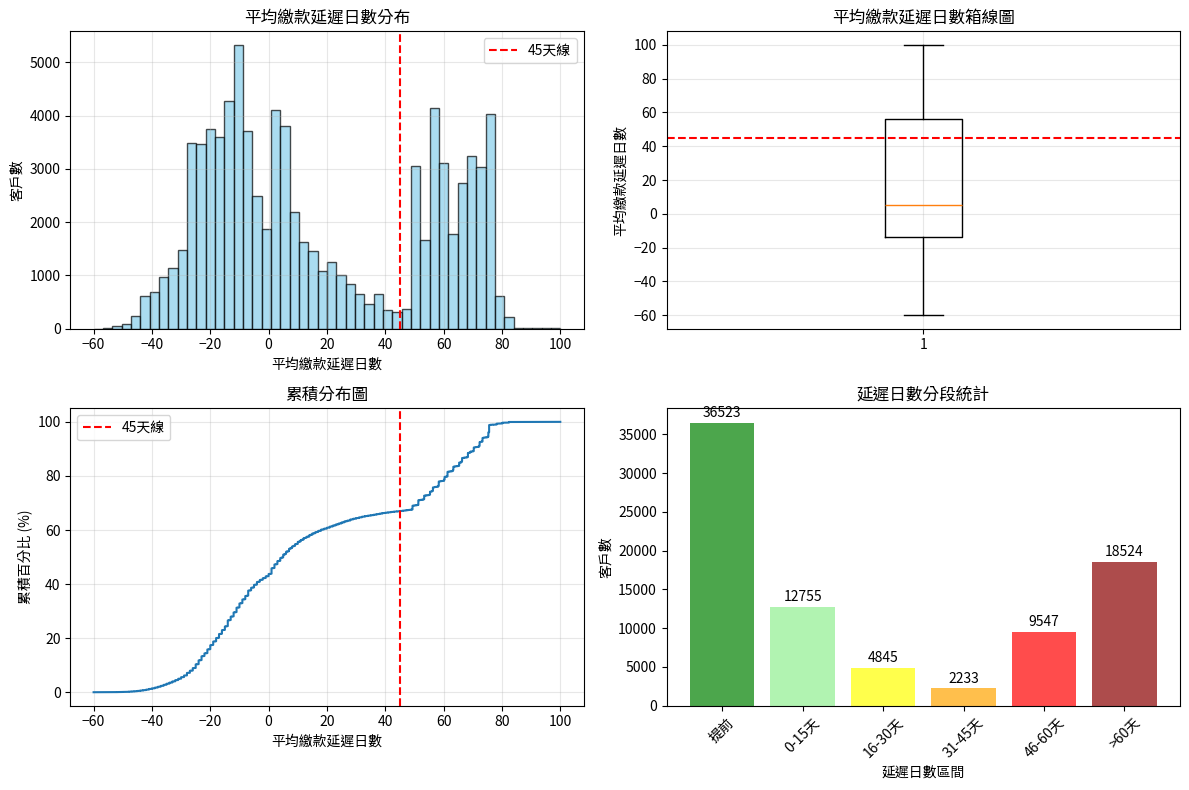


🎯 重點統計:
平均繳款延遲日數 < 45天的客戶: 56,969 筆
總客戶數: 85,118 筆
比例: 66.9%


In [8]:
# 視覺化平均繳款延遲日數分布
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if '平均繳款延遲日數' in ds_bill.columns:
    plt.figure(figsize=(12, 8))
    
    # 子圖1: 直方圖
    plt.subplot(2, 2, 1)
    plt.hist(ds_bill['平均繳款延遲日數'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(x=45, color='red', linestyle='--', label='45天線')
    plt.xlabel('平均繳款延遲日數')
    plt.ylabel('客戶數')
    plt.title('平均繳款延遲日數分布')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # 子圖2: 箱線圖
    plt.subplot(2, 2, 2)
    plt.boxplot(ds_bill['平均繳款延遲日數'].dropna())
    plt.axhline(y=45, color='red', linestyle='--', label='45天線')
    plt.ylabel('平均繳款延遲日數')
    plt.title('平均繳款延遲日數箱線圖')
    plt.grid(alpha=0.3)
    
    # 子圖3: 累積分布
    plt.subplot(2, 2, 3)
    delay_data = ds_bill['平均繳款延遲日數'].dropna().sort_values()
    cumulative_pct = np.arange(1, len(delay_data) + 1) / len(delay_data) * 100
    plt.plot(delay_data, cumulative_pct)
    plt.axvline(x=45, color='red', linestyle='--', label='45天線')
    plt.xlabel('平均繳款延遲日數')
    plt.ylabel('累積百分比 (%)')
    plt.title('累積分布圖')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # 子圖4: 分段統計條形圖
    plt.subplot(2, 2, 4)
    bins = [float('-inf'), 0, 15, 30, 45, 60, float('inf')]
    labels = ['提前', '0-15天', '16-30天', '31-45天', '46-60天', '>60天']
    counts = []
    
    for i in range(len(bins)-1):
        if bins[i] == float('-inf'):
            count = len(ds_bill[ds_bill['平均繳款延遲日數'] < bins[i+1]])
        elif bins[i+1] == float('inf'):
            count = len(ds_bill[ds_bill['平均繳款延遲日數'] > bins[i]])
        else:
            count = len(ds_bill[(ds_bill['平均繳款延遲日數'] > bins[i]) & 
                               (ds_bill['平均繳款延遲日數'] <= bins[i+1])])
        counts.append(count)
    
    colors = ['green', 'lightgreen', 'yellow', 'orange', 'red', 'darkred']
    bars = plt.bar(labels, counts, color=colors, alpha=0.7)
    plt.xlabel('延遲日數區間')
    plt.ylabel('客戶數')
    plt.title('延遲日數分段統計')
    plt.xticks(rotation=45)
    
    # 在條形圖上添加數值標籤
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                str(count), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # 特別標示45天以下的比例
    less_than_45_count = len(ds_bill[ds_bill['平均繳款延遲日數'] < 45])
    total_count = len(ds_bill)
    print(f"\n🎯 重點統計:")
    print(f"平均繳款延遲日數 < 45天的客戶: {less_than_45_count:,} 筆")
    print(f"總客戶數: {total_count:,} 筆")
    print(f"比例: {less_than_45_count/total_count*100:.1f}%")

ds_bill 資料集中的 '最常見繳費方式' 欄位，保留內容為 CVS臨櫃代收(7-11)、 廠商代收、 簡訊帳單臨櫃代收(7-11)、 金融機構轉帳、 當月繳帳單、 信用卡扣款、 APP臨櫃代收(7-11) ，其餘內容改 '其他繳款方式'

In [9]:
#import pandas as pd

# Assuming ds_bill is already loaded
# ds_bill = pd.read_csv('/content/drive/Othercomputers/我的筆記型電腦/ExpertBook/2025/用戶資料集/TrainData/ds_numService_with_billing.csv', sep=',')

# List of payment methods to keep
allowed_payment_methods = [
    "CVS臨櫃代收(7-11)",
    "廠商代收",
    "簡訊帳單臨櫃代收(7-11)",
    "金融機構轉帳",
    "當月繳帳單",
    "信用卡扣款",
    "APP臨櫃代收(7-11)"
]

# Replace other payment methods with '其他繳款方式'
ds_bill['最常見繳費方式'] = ds_bill['最常見繳費方式'].apply(lambda x: x if x in allowed_payment_methods else '其他繳款方式')

# Display the modified DataFrame (optional)
print(ds_bill.head())
print(ds_bill['最常見繳費方式'].value_counts())

        客編  平均繳款延遲日數         最常見繳費方式  繳別
0  1107235     -21.0  簡訊帳單臨櫃代收(7-11)  99
1   950469     -23.0   CVS臨櫃代收(7-11)  99
2   734283      25.0   CVS臨櫃代收(7-11)  99
3  1027561     -16.0   CVS臨櫃代收(7-11)  99
4  1028286     -41.0  簡訊帳單臨櫃代收(7-11)  99
最常見繳費方式
CVS臨櫃代收(7-11)     33768
廠商代收              28061
簡訊帳單臨櫃代收(7-11)    19759
金融機構轉帳             1504
當月繳帳單               897
信用卡扣款               823
其他繳款方式              281
APP臨櫃代收(7-11)        25
Name: count, dtype: int64


In [10]:
# ⬜ 1. 安裝／載入必要套件（Colab 已內建 pandas，通常不必另外安裝）
# import pandas as pd

# ⬜ 2. 讀取來源檔案
# ▸ 方式 A：直接從「檔案」側邊欄手動上傳 csv，再用下列路徑讀取
# file_path = "/content/ds_numService_with_billing.csv"   # ← 上傳後 Colab 的預設路徑

# ▸ 方式 B：若檔案在 Google Drive，先掛載 Drive
# from google.colab import drive
# drive.mount('/content/drive')
# file_path = "/content/drive/MyDrive/your_folder/ds_numService_with_billing.csv"

# df = pd.read_csv(file_path)
df = ds_bill.copy()

print("原始資料筆數：", df.shape)

# ⬜ 3. 指定要做 one‑hot 的欄位
one_hot_cols = ["繳別", "最常見繳費方式"]

# 自訂各欄位的前綴（prefix）以便辨識
prefix_map = {
    "繳別": "paytype",
    "最常見繳費方式": "paymethod"
}

# ⬜ 4. 進行 one‑hot
df_encoded = pd.get_dummies(
    df,
    columns=one_hot_cols,
    prefix=[prefix_map[col] for col in one_hot_cols],
    dtype=int               # 產生 0/1 的 int 欄位
)

# ⬜ 5. 儲存處理後檔案
output_path = "forTrain_ds_bill_24_onehot.csv"
df_encoded.to_csv(output_path, index=False, encoding="utf-8-sig")
print("完成 one‑hot 編碼，輸出檔案路徑:", output_path)

# ⬜ 6. 快速預覽前 5 列
df_encoded.head()


原始資料筆數： (85118, 4)
完成 one‑hot 編碼，輸出檔案路徑: forTrain_ds_bill_24_onehot.csv


,客編,平均繳款延遲日數,paytype_1,paytype_3,paytype_6,paytype_12,paytype_15,paytype_99,paymethod_APP臨櫃代收(7-11),paymethod_CVS臨櫃代收(7-11),paymethod_信用卡扣款,paymethod_其他繳款方式,paymethod_廠商代收,paymethod_當月繳帳單,paymethod_簡訊帳單臨櫃代收(7-11),paymethod_金融機構轉帳
0,1107235,-21.0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
1,950469,-23.0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
2,734283,25.0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
3,1027561,-16.0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
4,1028286,-41.0,0,0,0,0,0,1,0,0,0,0,0,0,1,0


In [11]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85118 entries, 0 to 85117
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   客編                        85118 non-null  int64  
 1   平均繳款延遲日數                  85118 non-null  float64
 2   paytype_1                 85118 non-null  int64  
 3   paytype_3                 85118 non-null  int64  
 4   paytype_6                 85118 non-null  int64  
 5   paytype_12                85118 non-null  int64  
 6   paytype_15                85118 non-null  int64  
 7   paytype_99                85118 non-null  int64  
 8   paymethod_APP臨櫃代收(7-11)   85118 non-null  int64  
 9   paymethod_CVS臨櫃代收(7-11)   85118 non-null  int64  
 10  paymethod_信用卡扣款           85118 non-null  int64  
 11  paymethod_其他繳款方式          85118 non-null  int64  
 12  paymethod_廠商代收            85118 non-null  int64  
 13  paymethod_當月繳帳單           85118 non-null  int64  
 14  paymet

In [12]:
df_encoded.shape

(85118, 16)